<a href="https://colab.research.google.com/github/DeemonDuck/upi-sentinel/blob/main/02_cnn_class_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UPI Sentinel – CNN with Class Weight Balancing
Handling Class Imbalance Using Cost-Sensitive Learning


## 1. Import Required Libraries


In [ ]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input


## 2. Data Loading and Feature Engineering


In [ ]:
# Load dataset
df = pd.read_csv("data/paysim.csv")

# Filter relevant transaction types
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Create engineered fraud-related features
df_model['account_emptied'] = (df_model['newbalanceOrig'] == 0).astype(int)
df_model['amount_matches_balance'] = (
    df_model['oldbalanceOrg'] == df_model['amount']
).astype(int)

# Encode transaction type
df_model = pd.get_dummies(
    df_model,
    columns=['type'],
    drop_first=True
)

# Define features and label
features = [
    'amount',
    'oldbalanceDest',
    'newbalanceDest',
    'account_emptied',
    'amount_matches_balance',
    'type_TRANSFER'
]

label = 'isFraud'

# Create final arrays
X_final = df_model[features].values.astype(np.float32)
y_final = df_model[label].values

print("Final X shape:", X_final.shape)
print("Final y shape:", y_final.shape)


Final X shape: (2770409, 6)
Final y shape: (2770409,)


**Observations:**

- The dataset has been successfully filtered to include only `TRANSFER` and `CASH_OUT` transactions.
- Two engineered behavioral features (`account_emptied` and `amount_matches_balance`) have been created based on prior fraud analysis.
- The categorical `type` feature has been encoded into numerical format.
- Final feature matrix `X_final` is structured as a 2D array with 6 predictive features.
- Target vector `y_final` contains the binary fraud labels.

The data is now prepared for train-test splitting.


## 3. Train-Test Split and Feature Scaling


In [ ]:
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    stratify=y_final,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (2216327, 6)
X_test_scaled shape: (554082, 6)


**Observations:**

- The dataset was split using stratified sampling to preserve fraud distribution in both training and testing sets.
- Feature scaling was applied using `StandardScaler`, which standardizes features to zero mean and unit variance.
- The scaler was fitted only on the training data to prevent data leakage.
- The resulting training and testing sets retain the original dimensionality (6 features).

The data is now properly split and scaled.

## 4. CNN with Class Weight Balancing


4.1 Compute Class Weights

In [ ]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(zip(np.unique(y_train), weights))
class_weights


{np.int64(0): np.float64(0.5014865887968677),
 np.int64(1): np.float64(168.67024353120243)}

4.2 Reshape Data for CNN

In [ ]:
n_features = X_train_scaled.shape[1]

X_train_cnn = X_train_scaled.reshape(-1, 1, n_features)
X_test_cnn = X_test_scaled.reshape(-1, 1, n_features)

print("Training shape:", X_train_cnn.shape)
print("Testing shape:", X_test_cnn.shape)


Training shape: (2216327, 1, 6)
Testing shape: (554082, 1, 6)


4.3 Build CNN Architecture

In [ ]:
model_weighted = Sequential([
    Input(shape=(1, n_features)),
    Conv1D(filters=32, kernel_size=1, activation='relu'),
    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_weighted.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_weighted.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 32)          │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,625 (14.16 KB)

 Trainable params: 3,625 (14.16 KB)

 Non-trainable params: 0 (0.00 B)

4.4 Train Model

In [ ]:
history_weighted = model_weighted.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_cnn, y_test),
    class_weight=class_weights,
    verbose=1
)


Epoch 1/10
34631/34631 ━━━━━━━━━━━━━━━━━━━━ 108s 3ms/step - accuracy: 0.9982 - loss: 0.0800 - val_accuracy: 1.0000 - val_loss: 4.3420e-04
Epoch 2/10
34631/34631 ━━━━━━━━━━━━━━━━━━━━ 102s 3ms/step - accuracy: 0.9999 - loss: 0.2749 - val_accuracy: 1.0000 - val_loss: 7.9706e-04
Epoch 3/10
34631/34631 ━━━━━━━━━━━━━━━━━━━━ 101s 3ms/step - accuracy: 0.9999 - loss: 0.1344 - val_accuracy: 1.0000 - val_loss: 9.0469e-04
Epoch 4/10
34631/34631 ━━━━━━━━━━━━━━━━━━━━ 105s 3ms/step - accuracy: 0.9993 - loss: 0.1484 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 5/10
34631/34631 ━━━━━━━━━━━━━━━━━━━━ 102s 3ms/step - accuracy: 0.9991 - loss: 0.1159 - val_accuracy: 1.0000 - val_loss: 7.7551e-04
Epoch 6/10
34631/34631 ━━━━━━━━━━━━━━━━━━━━ 101s 3ms/step - accuracy: 0.9995 - loss: 0.1092 - val_accuracy: 1.0000 - val_loss: 5.9136e-04
Epoch 7/10
34631/34631 ━━━━━━━━━━━━━━━━━━━━ 103s 3ms/step - accuracy: 0.9993 - loss: 0.3401 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 8/10
34631/34631 ━━━━━━━━━━━━━━━━━━━

4.5 Model Evaluation

In [ ]:
y_pred_proba = model_weighted.predict(X_test_cnn)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Non-Fraud', 'Fraud']
))


17316/17316 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    552439
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082



4.6 Confusion Matrix

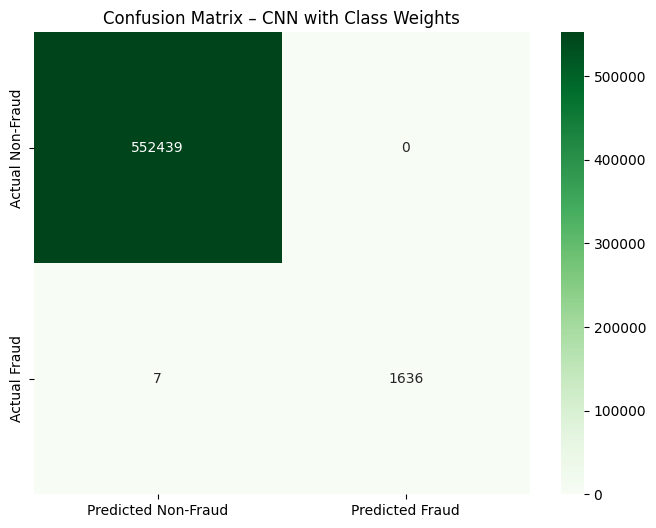

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
    yticklabels=['Actual Non-Fraud', 'Actual Fraud']
)

plt.title("Confusion Matrix – CNN with Class Weights")
plt.show()


### Performance Discussion

While the model achieves near-perfect precision and recall, this was not the intended outcome of building a generalized fraud detection system.

The unusually high performance suggests that certain engineered features (such as `account_emptied` and `amount_matches_balance`) strongly and almost deterministically separate fraud from non-fraud cases in the PaySim dataset.

Although effective on this synthetic dataset, such behavior may not generalize well to real-world fraud scenarios where patterns are less explicit and more dynamic.

This observation highlights the importance of careful feature engineering and realistic validation when developing fraud detection systems.
